In [1]:
import torch
import numpy as np
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForCausalLM
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



/home/adevitry/dLLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def add_gumbel_noise(logits, temperature):
    if temperature == 0:
        return logits
    logits = logits.to(torch.float64)
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (- torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise


def get_num_transfer_tokens(mask_index, steps):
    mask_num = mask_index.sum(dim=1, keepdim=True)
    base = mask_num // steps
    remainder = mask_num % steps
    num_transfer_tokens = torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, :remainder[i]] += 1
    return num_transfer_tokens



In [3]:
def generate(model, prompt, prompt_lens, pad_id, steps=256, max_new_tokens=256, block_size=64, temperature=0.0, cfg_scale=0.0, remasking="random"):
    mask_id = tokenizer.mask_token_id # type: ignore
    print(mask_id)
    batch_size = prompt.size(0)
    total_length = int(prompt_lens.max().item() + max_new_tokens)
    x = torch.full((batch_size, total_length), pad_id, dtype=torch.long, device=model.device)
    for i, length in enumerate(prompt_lens.tolist()):
        x[i, :length] = prompt[i, :length]
        x[i, length : length + max_new_tokens] = mask_id

    prompt_index = torch.arange(total_length, device=x.device).unsqueeze(0) < prompt_lens.unsqueeze(1)
    positions = torch.arange(total_length, device=x.device)

    assert max_new_tokens % block_size == 0
    num_blocks = max_new_tokens // block_size
    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    for num_block in range(num_blocks):
        block_start = prompt_lens + num_block * block_size
        block_end = block_start + block_size
        init_block_mask = (
            (positions.unsqueeze(0) >= block_start.unsqueeze(1))
            & (positions.unsqueeze(0) < block_end.unsqueeze(1))
            & (x == mask_id)
        )
        num_transfer_tokens = get_num_transfer_tokens(init_block_mask, steps_per_block)

        for i in range(steps_per_block):
            block_mask = (
                (positions.unsqueeze(0) >= block_start.unsqueeze(1))
                & (positions.unsqueeze(0) < block_end.unsqueeze(1))
                & (x == mask_id)
            )

            if cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                logits = model(x_).logits
                logits, un_logits = torch.chunk(logits, 2, dim=0)
                logits = un_logits + (cfg_scale + 1.0) * (logits - un_logits)
            else:
                logits = model(x).logits
            
            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1)

            if remasking == "low_confidence":
                p = F.softmax(logits, dim=-1)
                x0_p = torch.gather(p, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float)
            else:
                raise NotImplementedError(remasking)

            confidence = torch.full_like(x0_p, -np.inf)
            confidence = torch.where(block_mask, x0_p, confidence)

            x0 = torch.where(block_mask, x0, x)

            transfer_index = torch.zeros_like(x0, dtype=torch.bool, device=x0.device)
            for j in range(confidence.shape[0]):
                k = int(num_transfer_tokens[j, i].item())
                if k == 0:
                    continue
                _, select_index = torch.topk(confidence[j], k=k)
                transfer_index[j, select_index] = True
            x[transfer_index] = x0[transfer_index]

    return x


In [4]:
def get_generated_sentence_and_logprobs(model, prompt, prompt_lens, pad_id, steps=256, max_new_tokens=256, block_size=64):
    mask_id = tokenizer.mask_token_id # type: ignore
    batch_size = prompt.size(0)
    
    total_length = int(prompt_lens.max().item() + max_new_tokens)
    x = torch.full((batch_size, total_length), pad_id, dtype=torch.long, device=model.device)
    
    for i, length in enumerate(prompt_lens.tolist()):
        x[i, :length] = prompt[i, :length]
        x[i, length : length + max_new_tokens] = mask_id

    positions = torch.arange(total_length, device=x.device)
    
    assert max_new_tokens % block_size == 0
    num_blocks = max_new_tokens // block_size
    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    res_list = [defaultdict(dict) for _ in range(batch_size)]

    for num_block in range(num_blocks):
        block_start = prompt_lens + num_block * block_size
        block_end = block_start + block_size
        
        init_block_mask = (
            (positions.unsqueeze(0) >= block_start.unsqueeze(1))
            & (positions.unsqueeze(0) < block_end.unsqueeze(1))
            & (x == mask_id)
        )
        
        num_transfer_tokens = get_num_transfer_tokens(init_block_mask, steps_per_block)
        
        for i in range(steps_per_block):
            block_mask = (
                (positions.unsqueeze(0) >= block_start.unsqueeze(1))
                & (positions.unsqueeze(0) < block_end.unsqueeze(1))
                & (x == mask_id)
            )

            with torch.no_grad(): 
                logits = model(x).logits
            
            logits_with_noise = add_gumbel_noise(logits, temperature=0.0)
            x0 = torch.argmax(logits_with_noise, dim=-1)

            p = F.softmax(logits, dim=-1)
            x0_p = torch.gather(p, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)
            
            confidence = torch.full_like(x0_p, -np.inf)
            confidence = torch.where(block_mask, x0_p, confidence)

            transfer_index = torch.zeros_like(x, dtype=torch.bool, device=x.device)
            for j in range(batch_size):
                k = int(num_transfer_tokens[j, i].item())
                if k == 0:
                    continue
                _, select_index = torch.topk(confidence[j], k=k)
                transfer_index[j, select_index] = True
            
            
            x[transfer_index] = x0[transfer_index]
            
           
            for j in range(batch_size):
               
                current_block_probs = x0_p[j][init_block_mask[j]].detach().cpu().to(torch.float32)
                
                tokens_block = x[j][init_block_mask[j]]
                words_list = [tokenizer.decode(t).strip() for t in tokens_block] # type: ignore

                res_list[j][num_block][i] = (words_list, current_block_probs)
                
    return res_list

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# if device == "cpu":
#     print("⚠️ Attention: CUDA est indisponible, passage sur CPU (très lent pour un 8B)")

model_id = "GSAI-ML/LLaDA-8B-Instruct"

# Correction : 'dtype' au lieu de 'torch_dtype'
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    dtype=torch.bfloat16, 
    trust_remote_code=True
).to(device).eval()


for layer in model.model.layers:
    if not hasattr(layer, "attention_type"):
        layer.attention_type = "full_attention" 

    
tokenizer = AutoTokenizer.from_pretrained("dllm-hub/Qwen2.5-Coder-0.5B-Instruct-diffusion-mdlm-v0.1")

if tokenizer.pad_token_id is None and tokenizer.eos_token is not None:
    tokenizer.pad_token = tokenizer.eos_token
pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id or tokenizer.mask_token_id


messages = [
    [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": "Implement a BFS traversal in Python with clear inline comments."},
    ],
    [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": "Write a concise pytest that checks a Fibonacci implementation. "},
    ],
]

encoded = [
    tokenizer.apply_chat_template(m, add_generation_prompt=True, tokenize=True) 
    for m in messages
]
prompt_lens = torch.tensor([len(e['input_ids']) for e in encoded], dtype=torch.long)
max_prompt_len = prompt_lens.max().item()

prompt_tensor = torch.full((len(encoded), max_prompt_len), pad_id, dtype=torch.long) # type: ignore

for i, ids_dict in enumerate(encoded):
    ids = ids_dict['input_ids']
    prompt_tensor[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)



prompt_tensor = prompt_tensor.to(device)
prompt_lens = prompt_lens.to(device)
max_new_tokens = 256

results = get_generated_sentence_and_logprobs(
    model, prompt_tensor, prompt_lens, pad_id=pad_id, steps=256, max_new_tokens=max_new_tokens, block_size=64, 
)



/home/adevitry/dLLM/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Fetching 6 files:   0%|          | 0/6 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [27]:
def concat_lp(res):    
    final_logprobs = []
    nb_iterations = len(res[0].keys())
    for i in range(nb_iterations):
        lp_list = []
        for key in res.keys():
            logprobs = res[key][i][1].detach().cpu().to(torch.float32).numpy()
            lp_list.append(logprobs)
        final_logprobs.append(np.concatenate(lp_list, axis=0))
    return (final_logprobs)


def concat_text(res):
    final_text = []
    nb_iterations = len(res[0].keys())
    for i in range(nb_iterations):
        text_list = []
        for key in res.keys():
            text = res[key][i][0]
            text_list.append(text)
        final_text.append(np.concatenate(text_list, axis=0))
    return (final_text)


Final sentence: Sure ! Here 's an implementation of a BFS traversal in Python with clear inline comments : ``` python  def bfs (graph ):  """  Perform a BFS traversal on a given graph .  Args :  graph ( dict ): The graph represented as an adjacency list .  Returns :  list : A list of nodes visited during the BFS traversal .  """  visited = set ()  # Set to keep track of visited nodes   queue = []  # List to store the nodes to be visited   while queue :  node = queue .pop ( 0 )  # De queue the first node   if node not in visited :  queue .append (node )  # Add the node to the queue   visited .add (node )  # Add the node to the visited set   visited .append (node )  # Add the node to the visited list   return visited  `` ` The ` b fs ` function takes a graph represented as an adjacency list as input and returns a list of nodes visited during the BFS traversal . The function uses a set to keep track of visited nodes and a queue to store the nodes to be visited during the BFS traversal . <

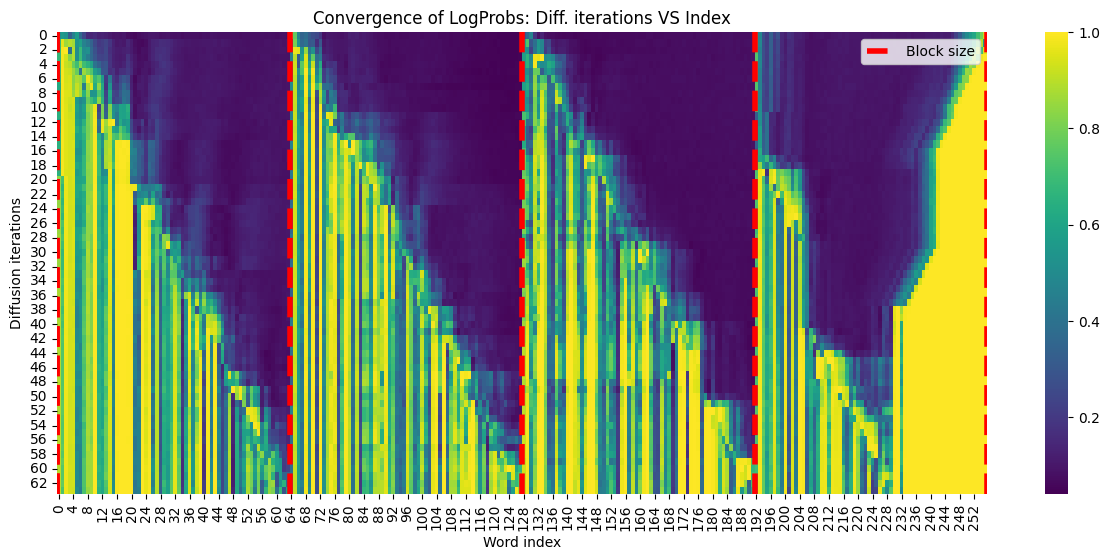

Final sentence: Sure ! Here 's a concise pytest that checks a Fibonacci implementation : ``` python  import pytest  def test _f ib onacci ():  """  Test the Fibonacci implementation .  Returns :  int : The Fibonacci number .  Returns :  int : The Fibonacci number .  Raises :  ValueError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  TypeError : If the input is not a positive integer .  Raises :  ValueError : If th

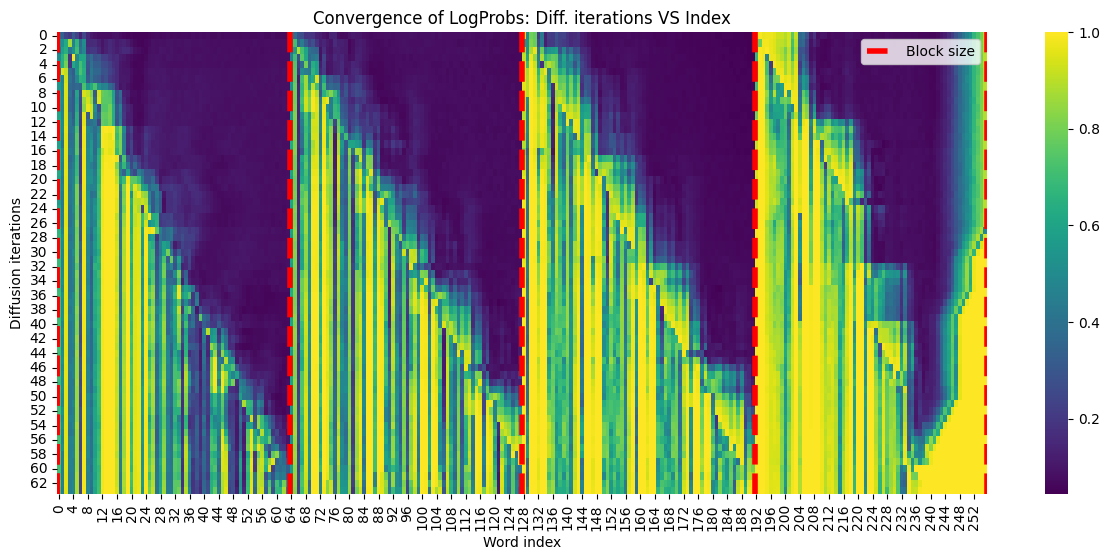

In [30]:
for j in range(len(results)):
    res = concat_lp(results[j])
    res_text = concat_text(results[j])
    plt.figure(figsize=(15, 6))
    sns.heatmap(res, cmap = 'viridis')
    plt.ylabel('Diffusion iterations')
    plt.xlabel('Word index')
    plt.title('Convergence of LogProbs: Diff. iterations VS Index')
    for i in range(5):
        if i == 0:
            plt.axvline(64*i, linewidth=4, color = 'red', linestyle= '--', label='Block size')
        plt.axvline(64*i, linewidth=4, color = 'red', linestyle= '--')

    plt.legend()
    print('Final sentence:', " ".join(res_text[-1]))
    plt.show()

In [29]:
for i in range(len(results)):
    print(f'==================== MESSAGE {i} ====================')
    for j in results[i].keys():
        print(f'------------- BLOCK {j} -------------')
        for k in (results[i][j].keys()):
            print(k, '.', results[i][j][k][0])

==================== MESSAGE 0 ====================
------------- BLOCK 0 -------------
0 . ['<|mask|>', '!', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>']
1 . ['<|mask|>', '!', '<|mask|>', "'s", '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>', '<|mask|>'